In [107]:
import sys
import importlib
sys.path.insert(0, '/home/lpsha/s154446/fractality/space_filling_model')
import space_filling
importlib.reload(space_filling)
from space_filling import get_geodataframe, run_ensemble, to_geodataframe, run_model
import powerlaw

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, '/home/lpsha/s154446/fractality')
from dgdc import get_dual_dir_con
import momepy
import numpy as np
from tqdm import tqdm


plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

  Model 1: converged at iteration 3702 with 7412 segments


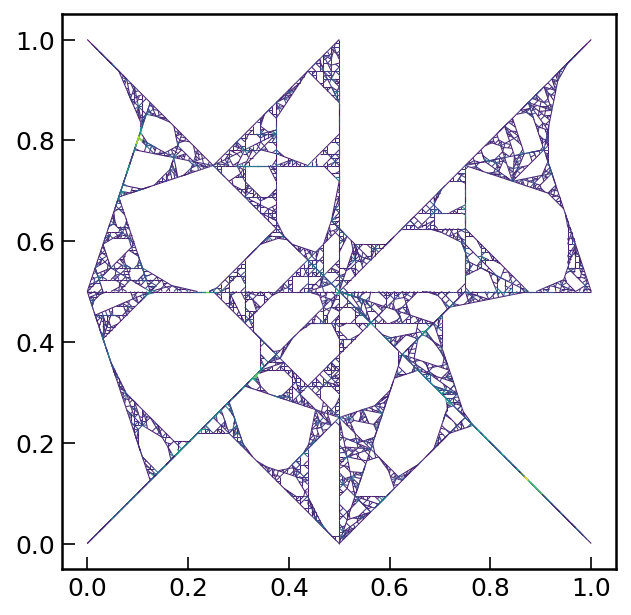

In [ ]:
gg=to_geodataframe(hello,'hello')
gg.plot(linewidth=0.5,column='deg_end')
plt.show()

In [108]:
# Model 1
model1 = get_geodataframe(model=1, min_length=0.012)
model1['osmid'] = model1.index
G = momepy.gdf_to_nx(model1, approach='primal')
gdf_merged1, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=20, data=G, enforce_degree2=False, simplify_roundabout=True)

  Model 1: converged at iteration 4787 with 9582 segments


In [109]:
# Model 2
model2 = get_geodataframe(model=2, min_angle=np.pi/3.8, area_coeff=0.01, min_length=0.01,seed=1) #angle 45 degree
model2['osmid'] = model2.index
G = momepy.gdf_to_nx(model2, approach='primal')
gdf_merged2, _, _, _ = get_dual_dir_con(t_buffer=20, a_threshold=20, data=G, enforce_degree2=False, simplify_roundabout=True)

  Model 2: converged at iteration 3004 with 5441 segments


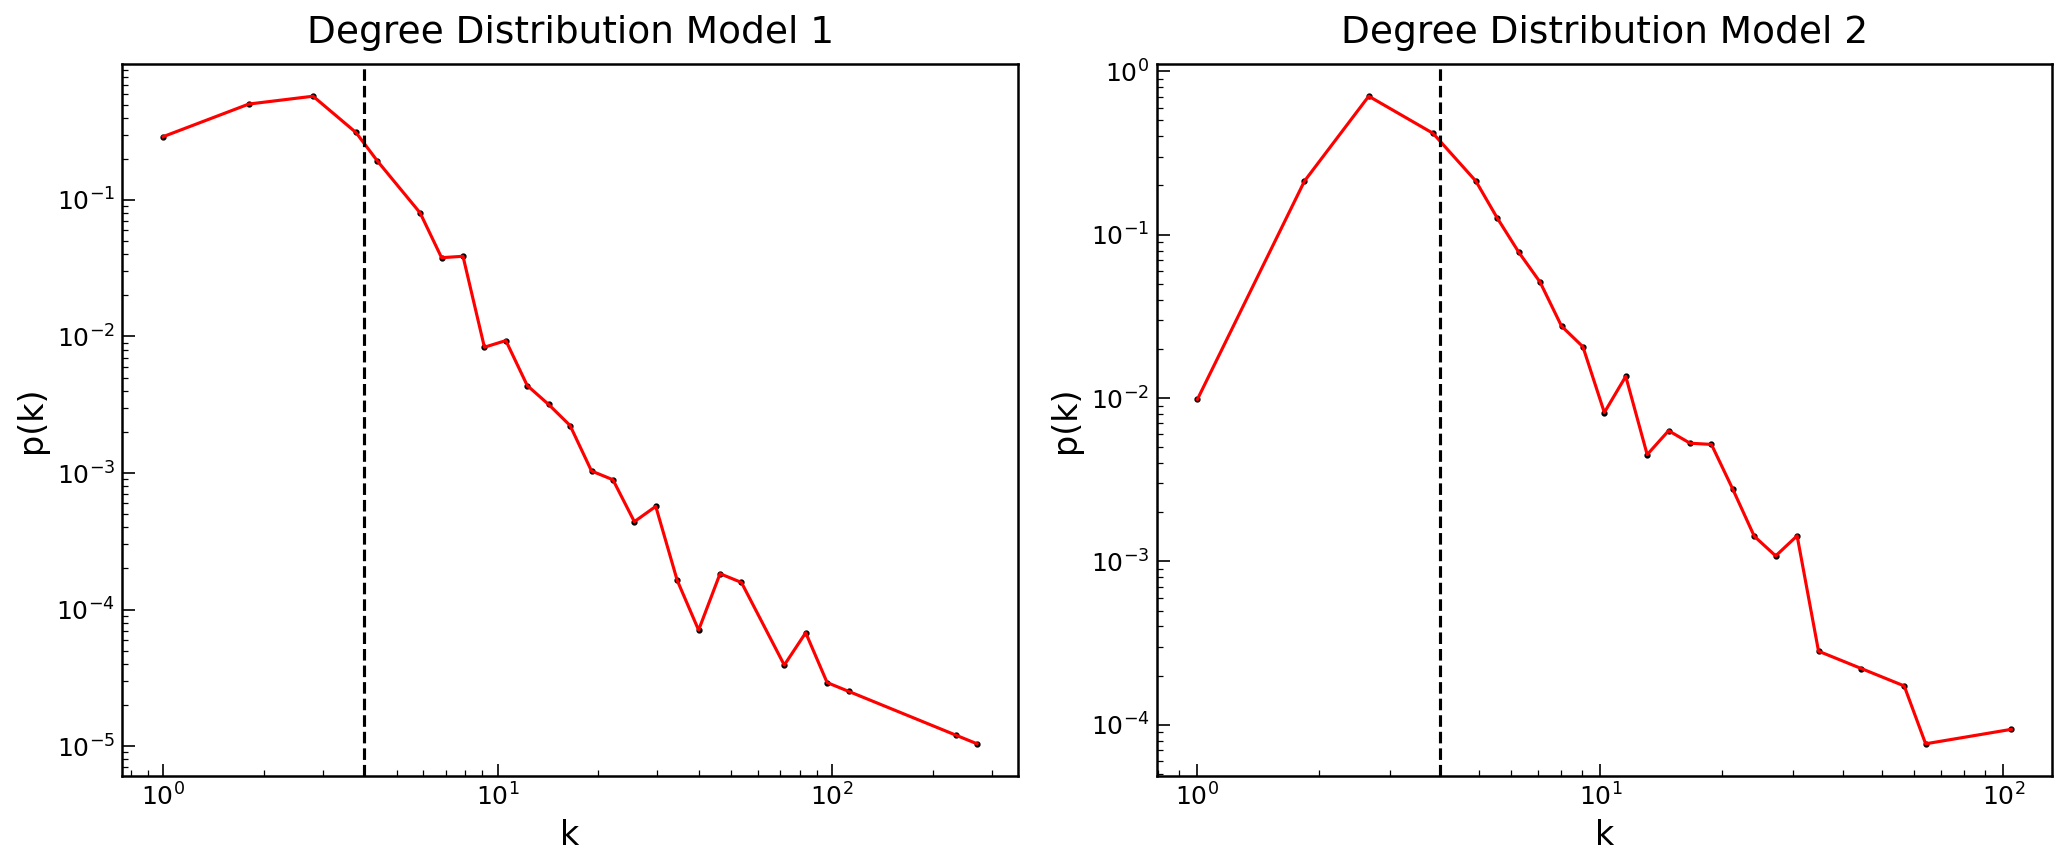

In [110]:
real_degree_sequence1=gdf_merged1['degree'].values
real_degree_sequence2=gdf_merged2['degree'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6),dpi=150)

ax = axs[0]
y, x = np.histogram(real_degree_sequence1, bins=np.logspace(0, np.log10(real_degree_sequence1.max()), len(np.unique(real_degree_sequence1))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.scatter(x_nn, y_nn, alpha=1, zorder=1, color='k', s=4)
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='red')
ax.set_ylabel('p(k)')
ax.set_xlabel('k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Degree Distribution Model 1")
ax.axvline(x=4, color='k', linestyle='--', label=r'$\phi$')

ax = axs[1]
y, x = np.histogram(real_degree_sequence2, bins=np.logspace(0, np.log10(real_degree_sequence2.max()), len(np.unique(real_degree_sequence2))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.scatter(x_nn, y_nn, alpha=1, zorder=1, color='k', s=4)
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='red')
ax.set_ylabel('p(k)')
ax.set_xlabel('k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Degree Distribution Model 2")
ax.axvline(x=4, color='k', linestyle='--', label=r'$\phi$')

plt.tight_layout()
plt.show()

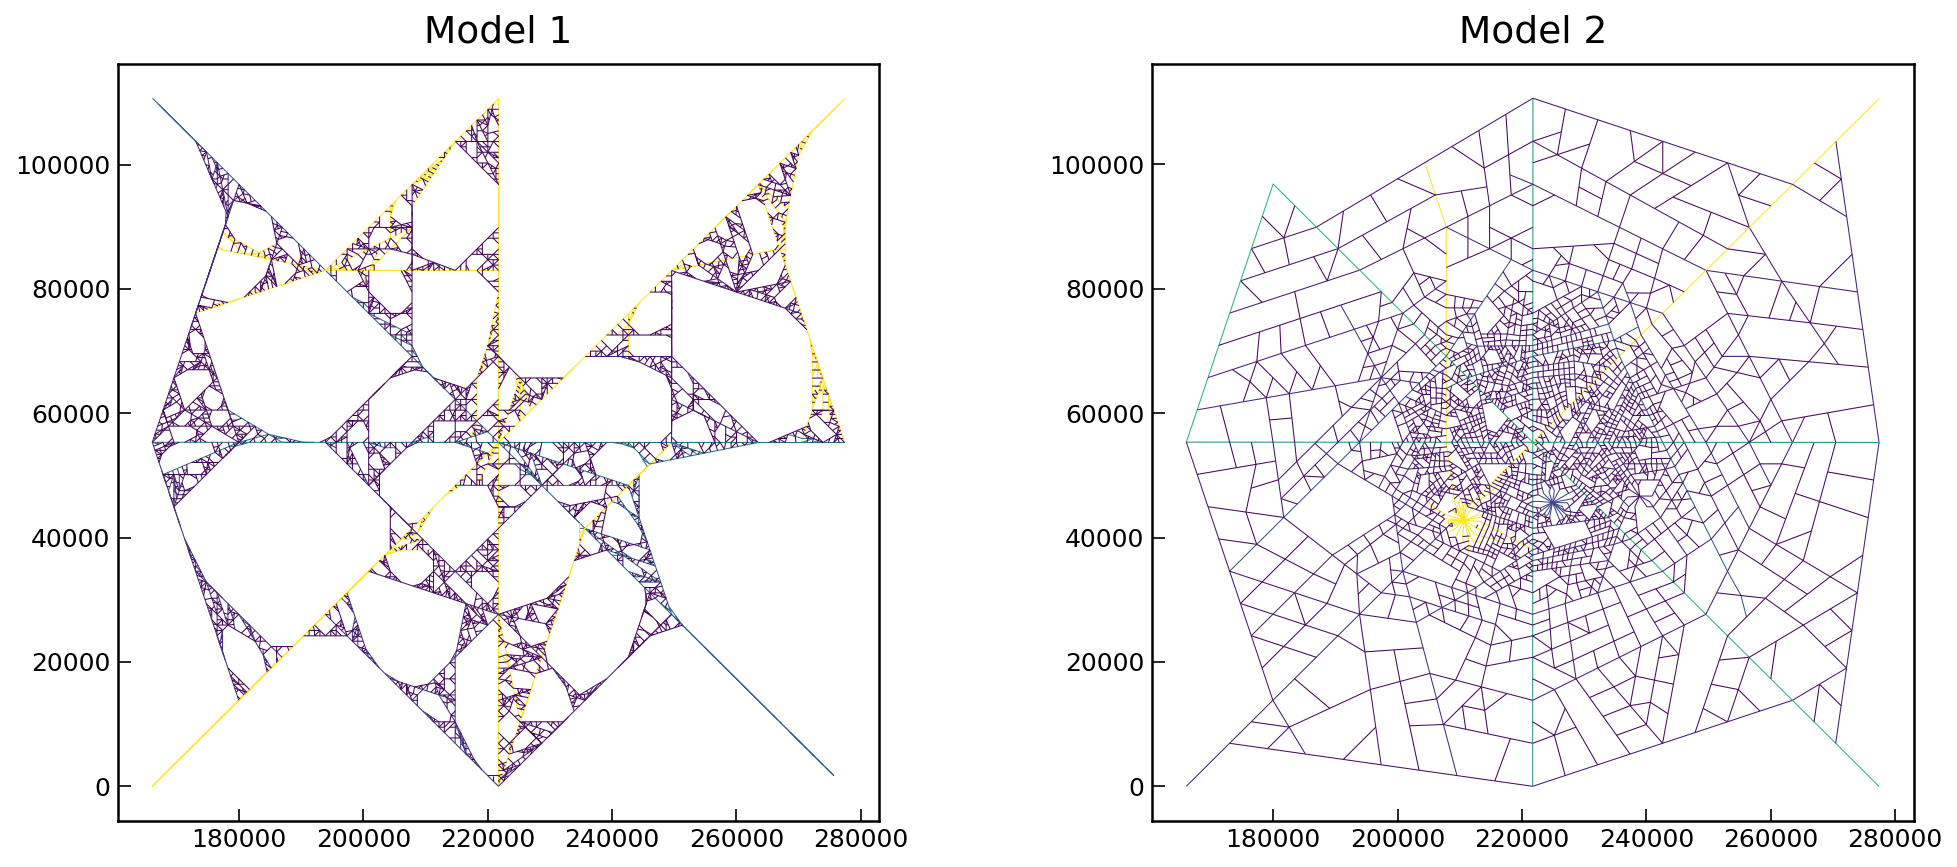

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gdf_merged1.plot(ax=axes[0], column='degree', linewidth=0.5)
axes[0].set_title('Model 1')
axes[0].set_aspect('equal')

gdf_merged2.plot(ax=axes[1], column='degree', linewidth=0.5)
axes[1].set_title('Model 2')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [112]:
def compute_ks(degree,min_range):
    distance = []
    ass = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        a = fit.alpha
        xmin = fit.xmin
        x_fit = degree[degree>xmin]
        
        distance.append(fit.power_law.D)
        ass.append(a) 

    return np.array(distance), min_range, ass

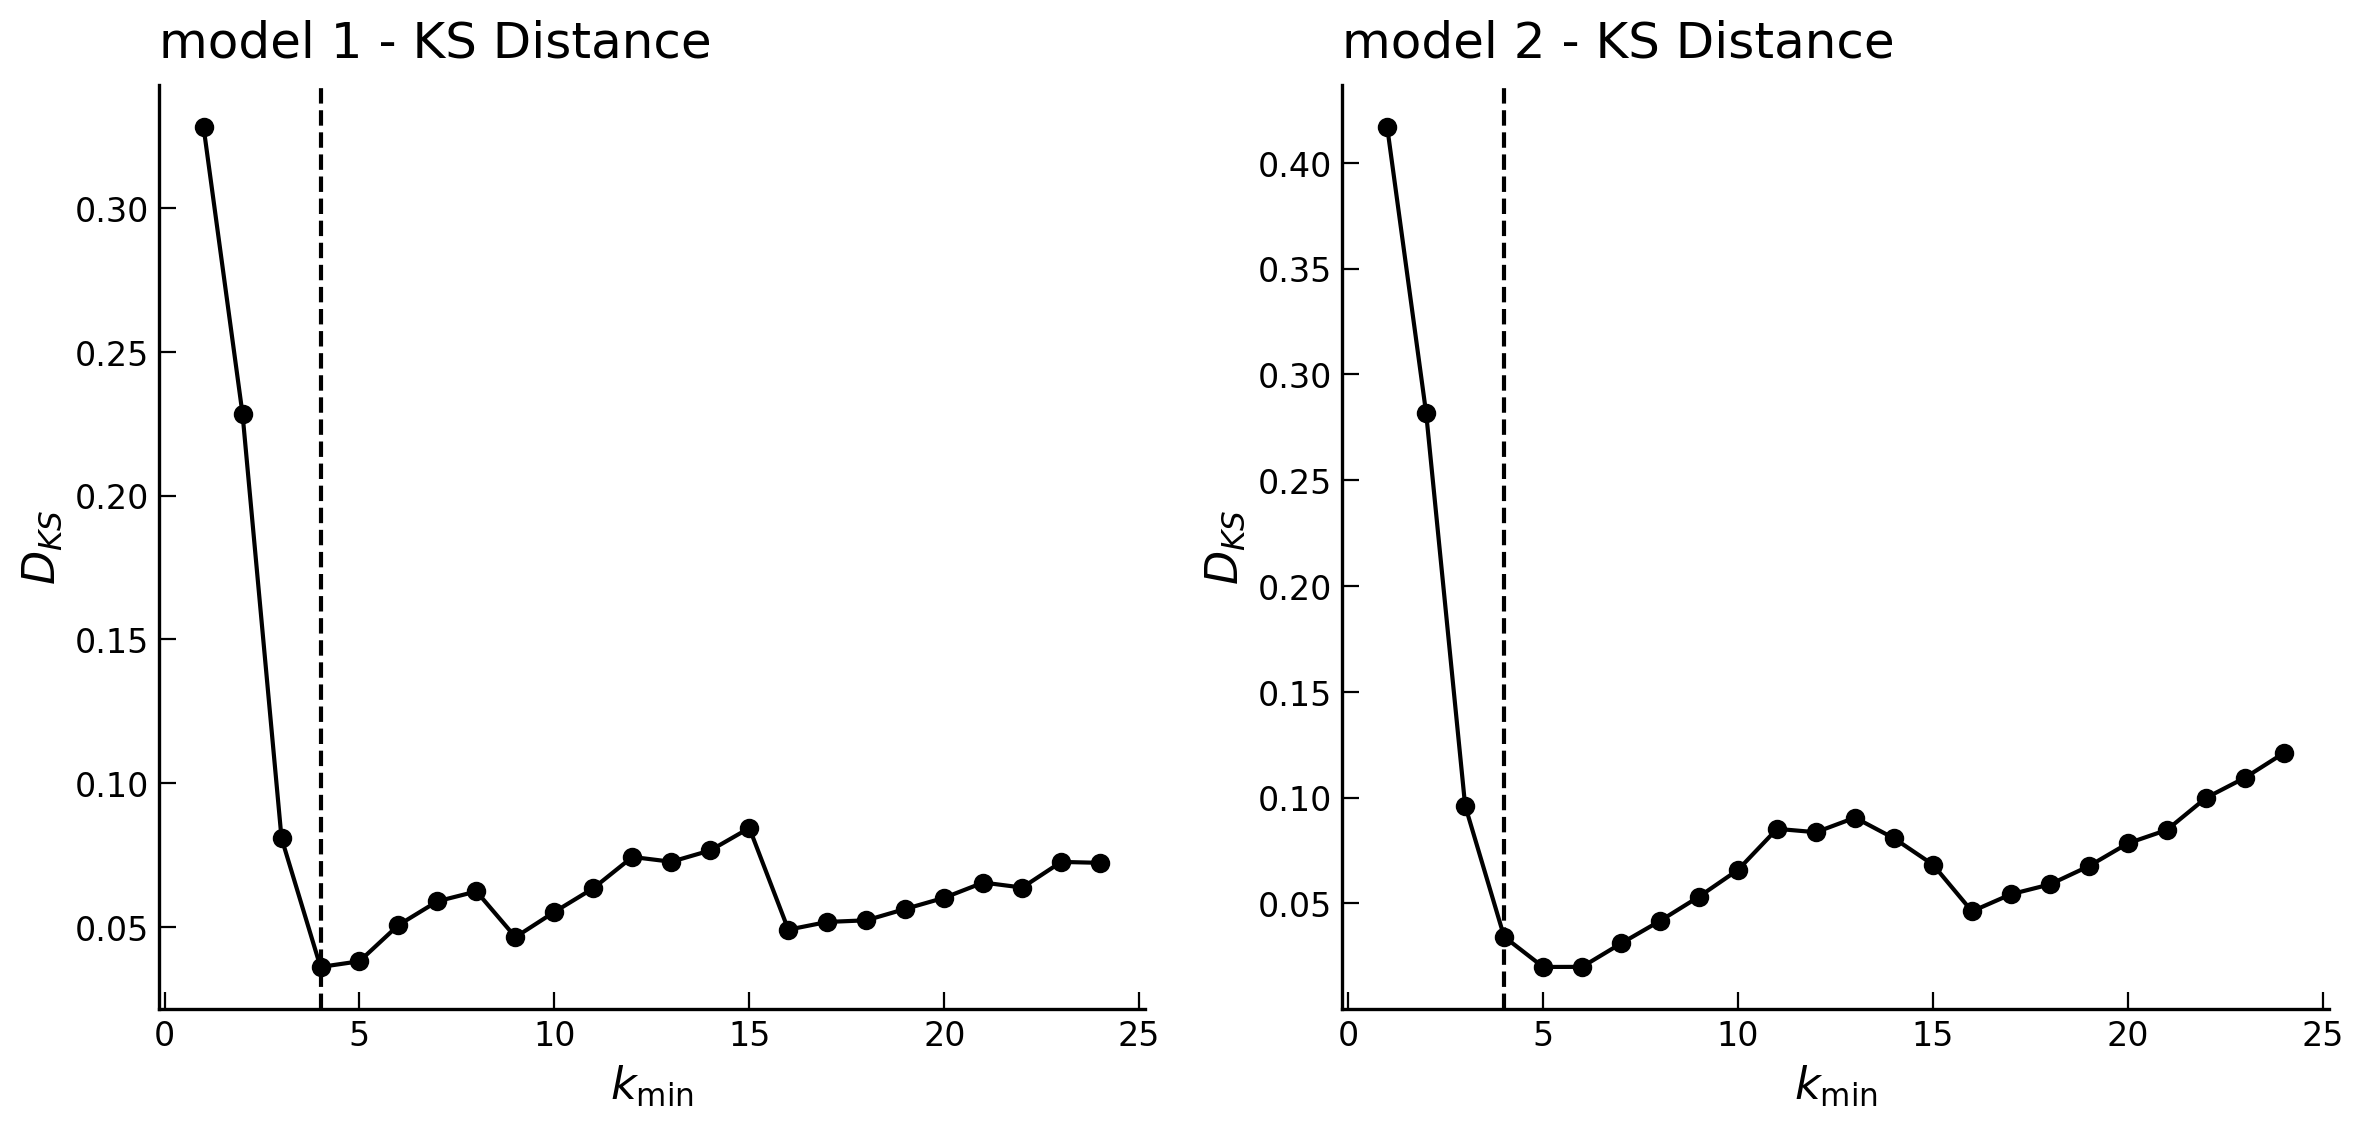

In [113]:
d=real_degree_sequence1
d=d[d != 0]
ks_dist1, xmins1, _ = compute_ks(d, range(1,25))

d2=real_degree_sequence2
d2=d2[d2 != 0]
ks_dist2, xmins2, _ = compute_ks(d2, range(1,25))

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,dpi=200,figsize=(14,6))

ax1.scatter(xmins1,ks_dist1,color='k')
ax1.plot(xmins1,ks_dist1,color='k')
ax1.set_xlabel(r'$k_{\min}$')
ax1.set_ylabel(r'$D_{KS}$')
ax1.set_title('model 1 - KS Distance', loc='left')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')

ax2.scatter(xmins2,ks_dist2,color='k')
ax2.plot(xmins2,ks_dist2,color='k')
ax2.set_xlabel(r'$k_{\min}$')
ax2.set_ylabel(r'$D_{KS}$')
ax2.set_title('model 2 - KS Distance', loc='left')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')

ax2.axvline(x=4, color='k', linestyle='--', label='Degree 2')
ax1.axvline(x=4, color='k', linestyle='--', label='Degree 2')
plt.show()

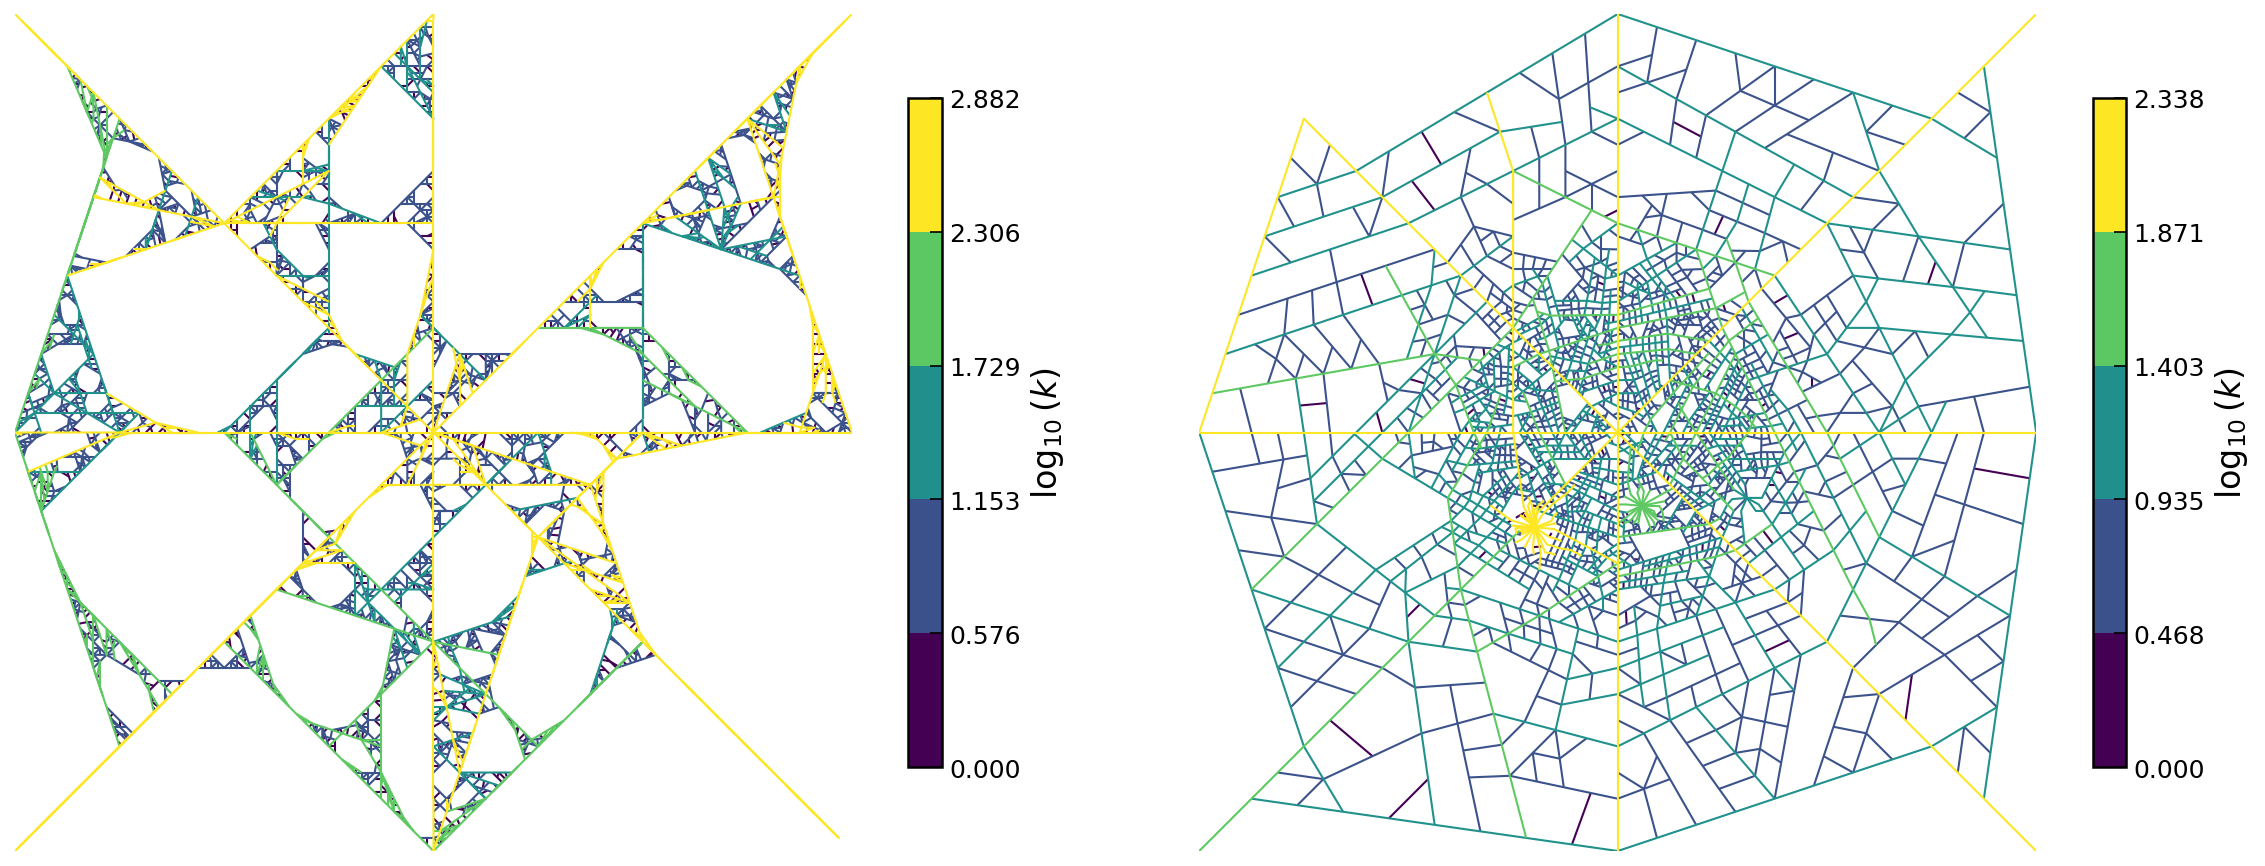

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

n_bins = 5
cmap = plt.cm.viridis

for ax, gdf in zip(axes, [gdf_merged1, gdf_merged2]):
    gdf_sorted = gdf.to_crs("EPSG:3857").sort_values('degree_log', ascending=True)
    gdf_sorted['degree_bin'] = pd.cut(gdf_sorted['degree_log'], bins=n_bins, labels=False)

    norm = mcolors.BoundaryNorm(
        boundaries=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1),
        ncolors=cmap.N
    )

    for b in range(n_bins):
        subset = gdf_sorted[gdf_sorted['degree_bin'] == b]
        subset.plot(ax=ax, color=cmap(b / (n_bins - 1)), linewidth=1)

    # Binned colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(
        sm, ax=ax, shrink=0.8, spacing='proportional',
        ticks=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1)
    )
    cbar.set_label(r'$\log_{10}(k)$')

    # Limit axes to data extent
    minx, miny, maxx, maxy = gdf_sorted.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [117]:
import matplotlib.lines as mlines

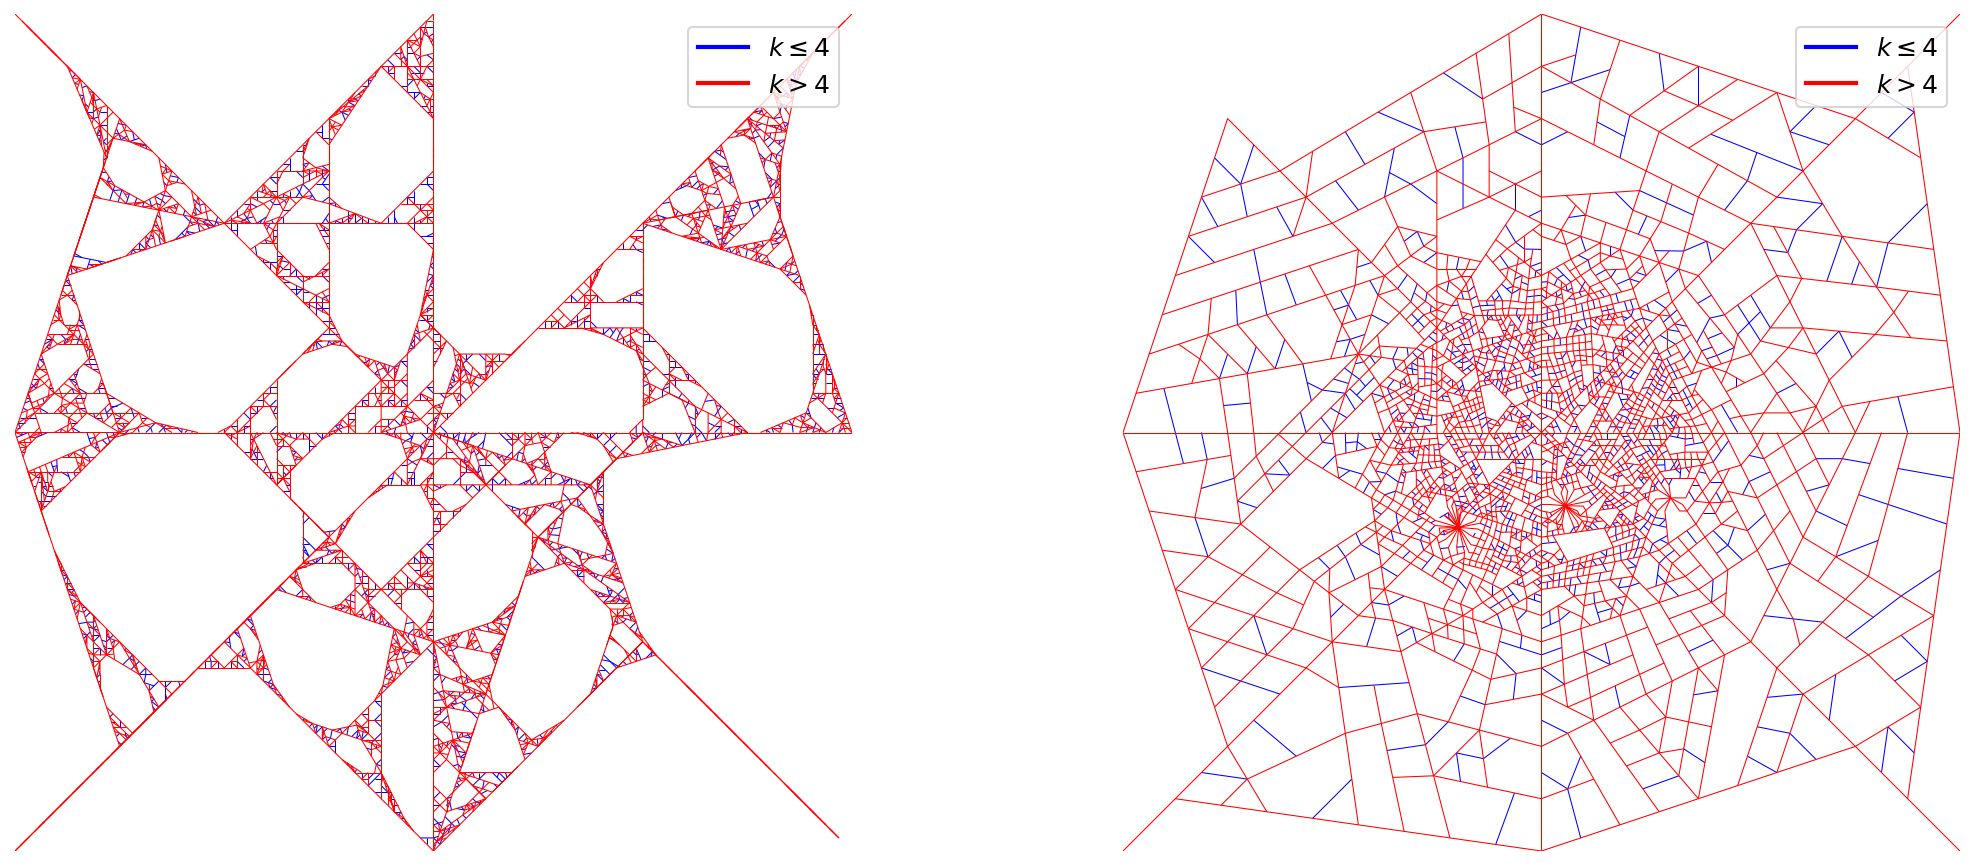

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

for ax, gdf in zip(axes, [gdf_merged1, gdf_merged2]):
    gdf_proj = gdf.to_crs("EPSG:3857").copy()
    gdf_proj['color'] = np.where(gdf_proj['degree'] <= 4, 'blue', 'red')

    # Plot low-degree first so high-degree edges sit on top
    for c in ['blue', 'red']:
        subset = gdf_proj[gdf_proj['color'] == c]
        subset.plot(ax=ax, color=c, linewidth=0.5)

    # Legend
    handles = [
        mlines.Line2D([], [], color='blue', linewidth=2, label=r'$k \leq 4$'),
        mlines.Line2D([], [], color='red', linewidth=2, label=r'$k > 4$'),
    ]
    ax.legend(handles=handles, loc='best', frameon=True)

    # Limit axes to data extent
    minx, miny, maxx, maxy = gdf_proj.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Ensemble

In [ ]:
for i in tqdm([1,2,3,4,5,7,8,9,11,12,12,13,14,15,16,17,18,19,20]):
    run = run_model(model=1, min_length=0.015,seed=i,verbose=False)

100%|█████████████████████████████████████████████| 11/11 [00:23<00:00,  2.14s/it]


100%|█████████████████████████████████████████████| 11/11 [01:58<00:00, 10.79s/it]


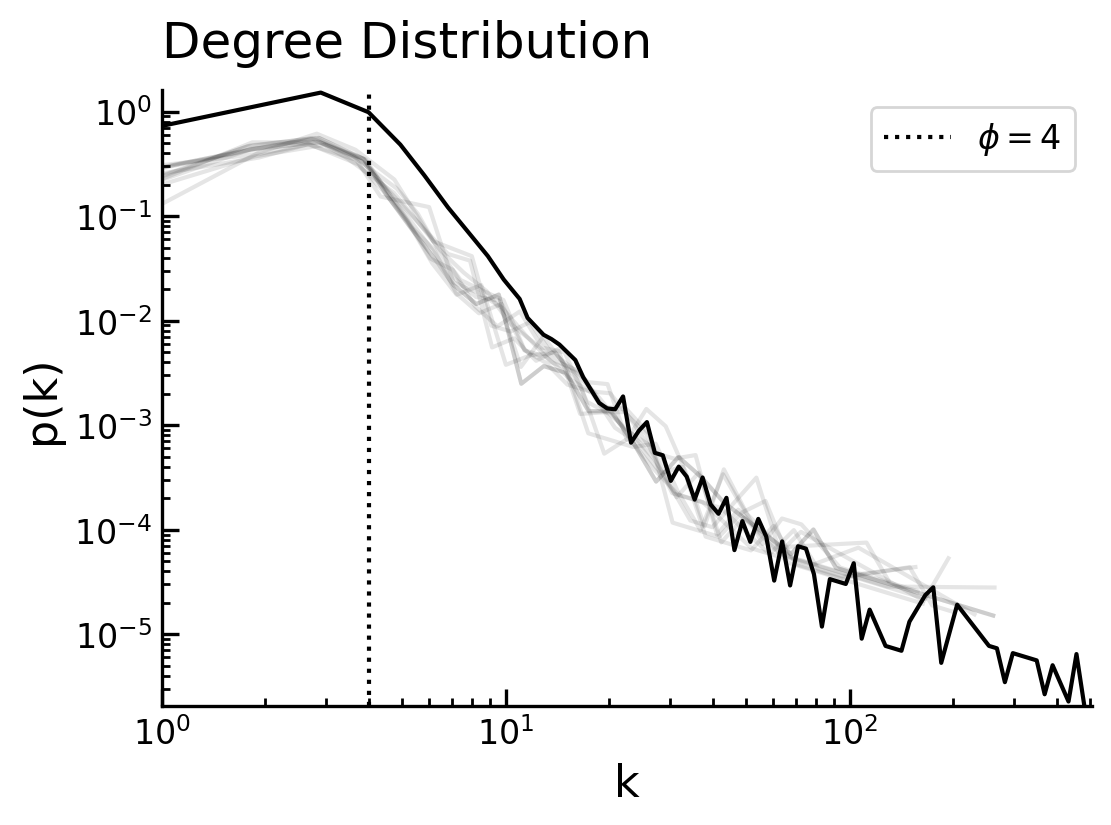

In [ ]:
full = np.array([])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4),dpi=200)

for i in tqdm([1,2,3,4,5,7,8,9,11,12,12,13,14,15,16,17,18,19,20]):
    run = run_model(model=1, min_length=0.015,seed=i,verbose=False)
    
    gdf = to_geodataframe(run,'run')
    gdf['osmid'] = gdf.index

    G = momepy.gdf_to_nx(gdf, approach='primal')
    gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=20, data=G, enforce_degree2=False, simplify_roundabout=True)
    
    d = gdf_merged['degree'].values
    d = d[d != 0]
    full=np.append(full, d)

    y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.1, zorder=2, color='k')


y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')

ax.yaxis.set_minor_formatter(plt.NullFormatter())

# Hide top/right spines (Nature style)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only bottom/left axes
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Major ticks (not too many)
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))

# Minor ticks
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))

# Appearance
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)

# Shade area from "x = 0" (small positive) up to x = 7
# ax.axvspan(xmin=0, xmax=3.99, color='blue', alpha=0.2, zorder=-1)
ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4),zorder=-1)
# ax.axvspan(xmin=4.01, xmax=1000, color='red', alpha=0.2, zorder=-1)
plt.legend()
# ax.set_xlim(right=1000)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title("Degree Distribution", loc='left', pad=12)
ax.set_xlabel("k")
ax.set_ylabel("p(k)")

plt.show()

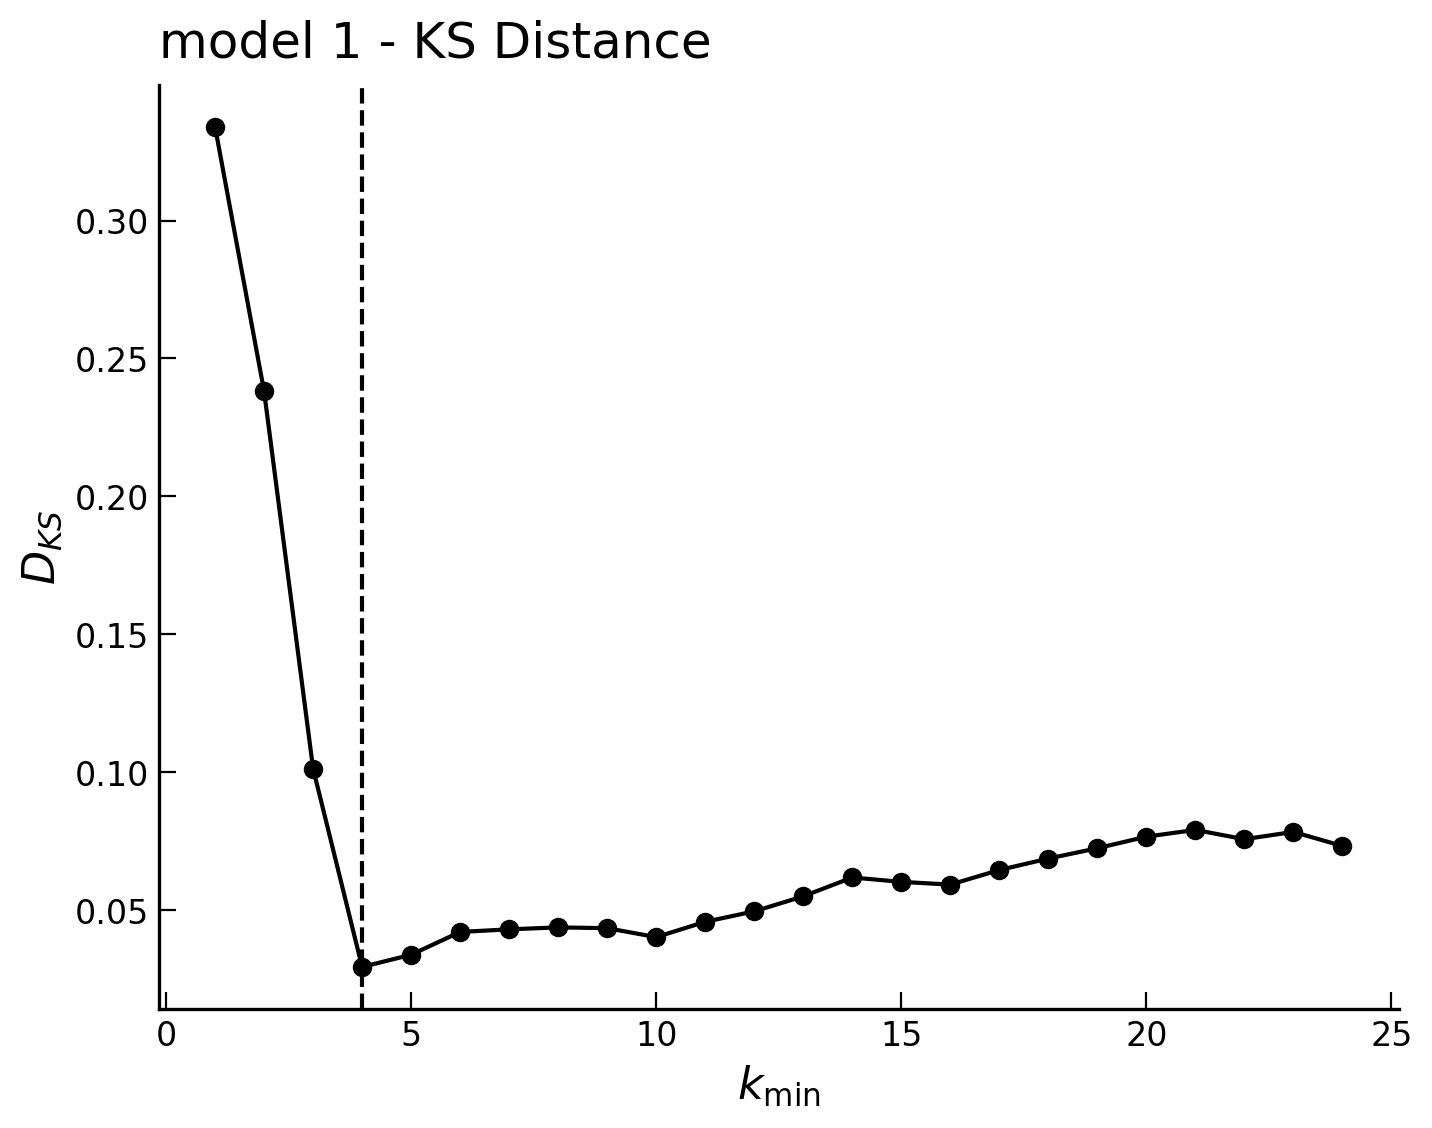

In [ ]:
d=full
d=d[d != 0]
ks_dist1, xmins1, _ = compute_ks(d, range(1,25))

fig, ax1 = plt.subplots(nrows=1,ncols=1,dpi=200,figsize=(8,6))
ax1.scatter(xmins1,ks_dist1,color='k')
ax1.plot(xmins1,ks_dist1,color='k')
ax1.set_xlabel(r'$k_{\min}$')
ax1.set_ylabel(r'$D_{KS}$')
ax1.set_title('model 1 - KS Distance', loc='left')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.axvline(x=4, color='k', linestyle='--', label='Degree 2')
plt.show()

In [ ]:
import momepy

In [ ]:
run = run_model(model=1, min_length=0.03,seed=i,verbose=False)
gdf = to_geodataframe(run,'run')
gdf['osmid'] = gdf.index
continuity = momepy.COINS(gdf)

/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/coins.py:103: UserWarning: Lines are between points dict_keys([(0.671875, 0.5), (0.6640625, 0.5)]) identical. Please revise input data to ensure no lines are identical or overlapping. You can check for duplicates using `gdf.geometry.duplicated()`. Assumingan angle of 0 degrees.
  self._best_link()
/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/coins.py:103: UserWarning: Lines are between points dict_keys([(0.578125, 0.0390625), (0.5625, 0.03125)]) identical. Please revise input data to ensure no lines are identical or overlapping. You can check for duplicates using `gdf.geometry.duplicated()`. Assumingan angle of 0 degrees.
  self._best_link()
/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/coins.py:103: UserWarning: Lines are between points dict_keys([(0.125, 0.125), (0.109375, 0.109375)]) identical. Please revise input data to ensure no lines are identical or overlapping. Y

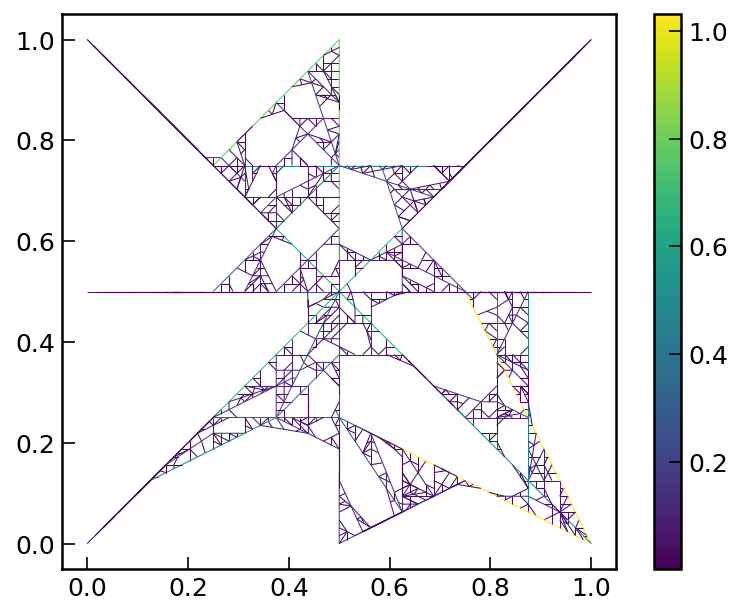

In [ ]:
stroke_gdf = continuity.stroke_gdf()
stroke_gdf['length'] = stroke_gdf.geometry.length
stroke_gdf.plot(linewidth=0.5, legend=True,column='length')
plt.show()

(np.float64(160503.75287280357),
 np.float64(283006.57355200994),
 np.float64(-5534.141887939572),
 np.float64(116216.97964673102))

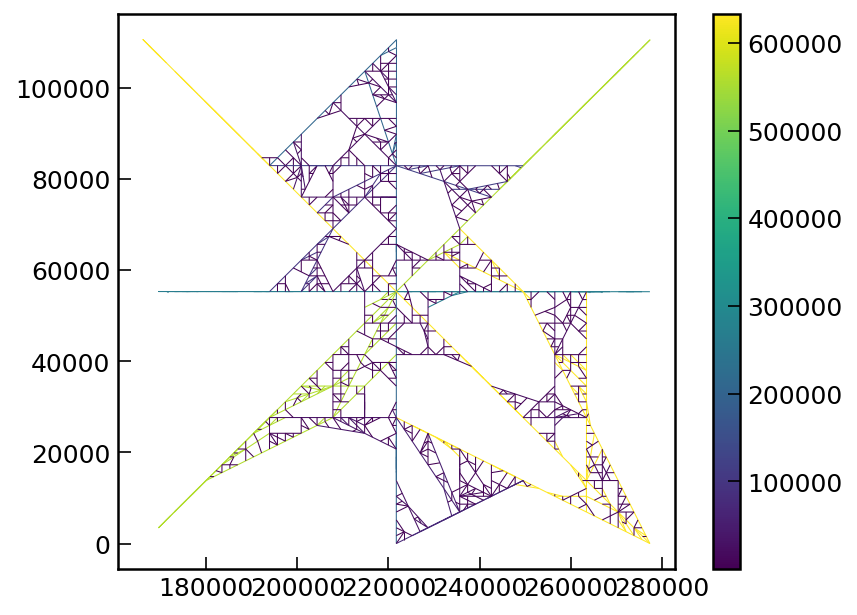

In [ ]:
G = momepy.gdf_to_nx(gdf, approach='primal')
gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=20, data=G, enforce_degree2=False, simplify_roundabout=True)
gdf_merged.plot(column='length', linewidth=0.5, legend=True)
plt.axis()